In [1]:
%cd ..

/home/bhchen/LearnKalmanGain


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

/tmp/ipykernel_1336111/3245118550.py:232: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(file_name)


36
38
19
201
Saved main figure to: /home/bhchen/LearnKalmanGain/save/figures/w2diff.pdf
Saved legend figure to: /home/bhchen/LearnKalmanGain/save/figures/w2diff_legend.pdf


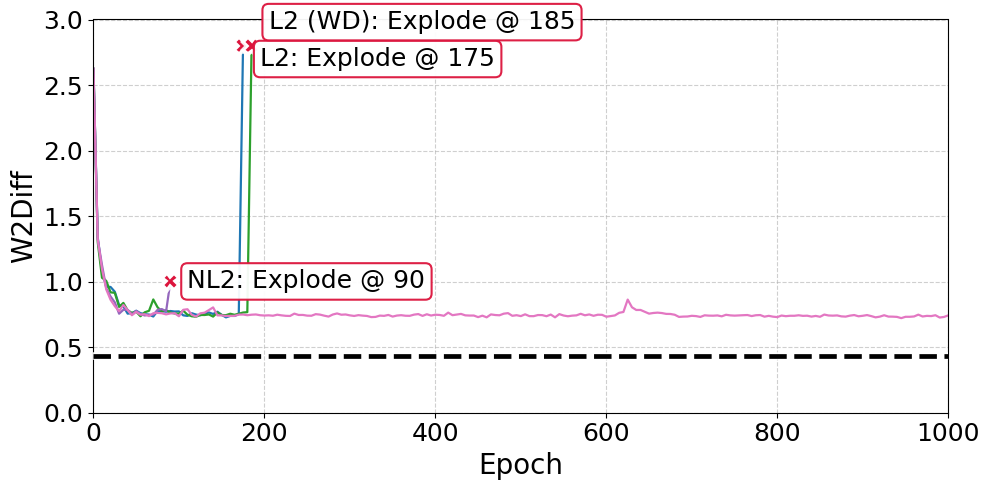

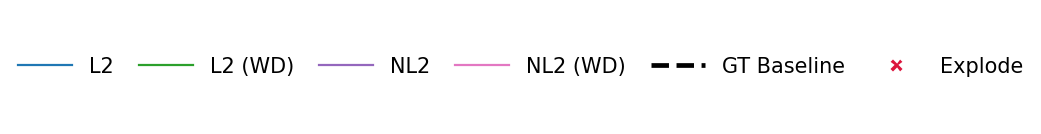

In [34]:
import torch
import os
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe  # For baseline glow effect
from matplotlib.transforms import Bbox

# =================== Style & layout knobs (easy to tune) ===================
FIGSIZE_MAIN = (10, 5)
FIGSIZE_LEGEND = (10, 1.2)

MAIN_LINE_WIDTH = 1.6
USE_MARKERS = False
MARKER_STYLE = None if not USE_MARKERS else 'o'

BASELINE_COLOR = "k"
BASELINE_LS = "--"
BASELINE_LW = 3.4
BASELINE_ZORDER = 10
ADD_BASELINE_GLOW = True
GLOW_WIDTH_EXTRA = 2.0
GLOW_COLOR = "white"
GLOW_ALPHA = 0.9

# Explode marker
EXP_MARKER = 'X'
EXP_MARKER_SIZE = 120
EXP_COLOR = "crimson"
EXP_EDGE_COLOR = "white"
EXP_EDGE_WIDTH = 1.5
EXP_ZORDER = 12
EXP_ADD_GLOW = True

# Explode label (boxed)
EXP_ANNOTATE = True
EXP_ANN_FONTSIZE = 18
EXP_ANN_DX = 20                # data units (epochs), place to the right of the cross
EXP_ANN_Y_MAX = 2.8            # annotation y cap
EXP_ANN_BOX = dict(
    boxstyle="round,pad=0.25",
    fc="white",
    ec=EXP_COLOR,
    lw=1.5,
    alpha=0.95
)

# Anti-overlap controls (pixel space)
EXP_AVOID_OVERLAP = True
EXP_ANN_PIXEL_STEP = 16        # base vertical step in pixels for local search (still used)
EXP_MAX_STEPS = 80             # safety cap for local search

# Axes ranges and grid
X_LIM = (-0.5, 1000)
Y_LIM = (0, 3)
GRID_LS = "--"
GRID_ALPHA = 0.6

# =================== Font sizes (centralized controls) =====================
AXIS_LABEL_FONTSIZE = 20
TICK_FONTSIZE = 18
LEGEND_FONTSIZE = 15
# (No title)

# ===========================================================================

def bboxes_overlap(b1: Bbox, b2: Bbox) -> bool:
    """Return True if two Bbox objects overlap in display coordinates."""
    return (b1.x0 < b2.x1) and (b1.x1 > b2.x0) and (b1.y0 < b2.y1) and (b1.y1 > b2.y0)

def data_delta_for_pixel_delta_y(ax, pixel_dy: float) -> float:
    """Convert a vertical pixel offset to data units for the given axes."""
    inv = ax.transData.inverted()
    p0 = inv.transform((0, 0))
    p1 = inv.transform((0, pixel_dy))
    return p1[1] - p0[1]

def compute_ann_bbox(ax, fig, ann, pad_x=1.04, pad_y=1.12) -> Bbox:
    """Get an annotation bbox in display coords, slightly expanded for visual padding."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    return ann.get_window_extent(renderer=renderer).expanded(pad_x, pad_y)

def nearest_fit_local(ax, fig, ann, anns_accepted_bboxes, y_init, y_min_allowed, y_max_allowed,
                      pixel_step=16, max_steps=80, up_first=False):
    """
    Local bidirectional nearest-fit search around y_init to avoid already accepted boxes.
    Keeps drift small and bounded.
    """
    def collides_with_accepted():
        bb = compute_ann_bbox(ax, fig, ann)
        return any(bboxes_overlap(bb, obb) for obb in anns_accepted_bboxes)

    # Try the initial position first
    x_now, _ = ann.get_position()
    ann.set_position((x_now, y_init))
    fig.canvas.draw()
    if not collides_with_accepted():
        return y_init, compute_ann_bbox(ax, fig, ann)

    # Convert pixel step to data step
    step_data = abs(data_delta_for_pixel_delta_y(ax, pixel_step))
    # Cap the maximum total travel in pixels
    MAX_SHIFT_PIXELS = 96
    max_k_cap = max(1, int(MAX_SHIFT_PIXELS / max(1, pixel_step)))
    max_k = min(max_steps, max_k_cap)

    # Order of directions
    signs = (-1, +1) if up_first else (+1, -1)

    for k in range(1, max_k + 1):
        for s in signs:
            y_try = y_init + s * k * step_data
            y_try = min(max(y_try, y_min_allowed), y_max_allowed)
            ann.set_position((x_now, y_try))
            fig.canvas.draw()
            if not collides_with_accepted():
                return y_try, compute_ann_bbox(ax, fig, ann)

    # If all failed, stick to the initial y (might collide; will be fixed globally)
    ann.set_position((x_now, y_init))
    fig.canvas.draw()
    return y_init, compute_ann_bbox(ax, fig, ann)

def place_nonoverlap_with_min_separation(ax, fig, ann_items, pixel_gap_extra=2, max_iter=3):
    """
    Deterministic, fast, and stable non-overlap placement with minimum separations.

    Idea:
      - Sort annotations by their target y (y0) (ascending).
      - Compute each bbox height in pixels, convert to data-units "half-heights".
      - For adjacent pair (i, i+1), required separation in data units is:
            sep[i] = half_h_i + half_h_{i+1} + gap_extra_data
        where gap_extra_data is pixel_gap_extra converted to data-units.
      - If total required span exceeds available space, scale all sep by a factor < 1
        to ensure feasibility (keeps relative sizes).
      - Run a forward pass to enforce lower bounds and separations.
      - Run a backward pass to enforce upper bounds and separations.
      - Repeat a small number of times (max_iter), typically 2 passes suffice.

    Inputs:
      ann_items: list of dicts with keys:
         - "ann": the Annotation object
         - "y_min": lower bound
         - "y_max": upper bound
         - "y_target": preferred y (near where the marker is)
    """
    if len(ann_items) <= 1:
        return

    # Prepare: compute bboxes and pixel heights
    bboxes = []
    pix_to_data = lambda py: data_delta_for_pixel_delta_y(ax, py)
    for it in ann_items:
        bb = compute_ann_bbox(ax, fig, it["ann"])
        bboxes.append(bb)

    # Compute per-annotation half heights in pixels (with padding already inside compute_ann_bbox)
    half_heights_pix = [(bb.y1 - bb.y0) * 0.5 for bb in bboxes]
    gap_extra_data = abs(pix_to_data(pixel_gap_extra))

    # Sort by target y (ascending)
    order = sorted(range(len(ann_items)), key=lambda k: ann_items[k]["y_target"])
    # Build arrays in sorted order
    y_min = [ann_items[k]["y_min"] for k in order]
    y_max = [ann_items[k]["y_max"] for k in order]
    y_tar = [ann_items[k]["y_target"] for k in order]
    hh_pix = [half_heights_pix[k] for k in order]

    # Compute separations between neighbors in DATA units
    sep = []
    for i in range(len(order) - 1):
        req_pixels = hh_pix[i] + hh_pix[i + 1] + pixel_gap_extra
        sep.append(abs(pix_to_data(req_pixels)))

    # Ensure feasibility by scaling separations if necessary
    total_sep = sum(sep) if sep else 0.0
    span_min = min(y_min)
    span_max = max(y_max)
    avail = max(0.0, span_max - span_min)

    if total_sep > 0 and total_sep > avail * 0.98:
        scale = (avail * 0.98) / total_sep
        sep = [s * scale for s in sep]

    # Initialize y with the targets clamped to bounds
    y = [min(max(y_tar[i], y_min[i]), y_max[i]) for i in range(len(order))]

    # Iterative two-pass relaxation (few iterations for robustness)
    for _ in range(max_iter):
        # Forward pass: enforce lower bounds + separations (bottom to top)
        y[0] = max(y[0], y_min[0])
        for i in range(1, len(y)):
            lower = y[i - 1] + sep[i - 1]
            y[i] = max(y[i], lower, y_min[i])

        # Backward pass: enforce upper bounds + separations (top to bottom)
        y[-1] = min(y[-1], y_max[-1])
        for i in range(len(y) - 2, -1, -1):
            upper = y[i + 1] - sep[i]
            y[i] = min(y[i], upper, y_max[i])

    # Write back to annotations in their original order
    for idx_sorted, k in enumerate(order):
        x_now, _ = ann_items[k]["ann"].get_position()
        ann_items[k]["ann"].set_position((x_now, y[idx_sorted]))

# Load baseline result
inherent_unc_results = torch.load(
    os.path.join("save", "benchmark", "linear_inherent_unc_N10_resample100_len500_10rand.pt"),
    weights_only=True
)
Base_W2 = inherent_unc_results['mean_w2_diff']

folder_names = [
    '2025-10-21_20-09linear_1_10_60_8192_l2_joint_CorrTerms',
    '2025-10-21_20-34linear_1_10_60_8192_l2_joint_CorrTerms',
    '2025-10-21_17-37linear_1_10_60_8192_nl2_joint_CorrTerms',
    '2025-10-21_17-50linear_1_10_60_8192_nl2_joint_CorrTerms',
]
method_names = ['L2', 'L2 (WD)', 'NL2', 'NL2 (WD)']

# --- Main figure ---
fig_w2diff, ax_w2diff = plt.subplots(figsize=FIGSIZE_MAIN)
explode_label_added = False

# Collect annotations for global placement
anns_pending = []  # dicts: {"ann", "y_min", "y_max", "y_target"}

for i, folder_name in enumerate(folder_names):
    file_name = os.path.join('save', 'linear_explode_checks', folder_name, 'training_records.pt')

    # Load and sanity-check
    data = torch.load(file_name)
    w2_diff, test_epochs = data.get('mean_w2_diff'), data.get('test_epochs')
    print(len(test_epochs))

    if not w2_diff:
        print(f"Skipping plot for {folder_name} due to missing data.")
        continue
    if len(w2_diff) != len(test_epochs):
        print(f"Warning: Data length mismatch for {folder_name}. Expected {len(test_epochs)} points, found {len(w2_diff)}.")
        continue

    # Plot curves (no markers)
    w2_diff = [min(v, Y_LIM[1]-0.2) for v in w2_diff]  # clamp for visibility
    ax_w2diff.plot(
        test_epochs, w2_diff,
        linestyle='-',
        marker=MARKER_STYLE,
        linewidth=MAIN_LINE_WIDTH,
        label=method_names[i]
    )

    # Detect and mark explode
    if len(test_epochs) < 201:
        x_exp = test_epochs[-1]
        y_exp = w2_diff[-1]

        # Clamp marker Y to ensure visibility within axes (pin to top if > top limit)
        y_plot = min(float(y_exp), float(Y_LIM[1]-0.2))

        # Red "X" marker (only one legend entry for 'Explode')
        exp_label = 'Explode' if not explode_label_added else None
        m, = ax_w2diff.plot(
            [x_exp], [y_plot],
            linestyle='None',
            marker=EXP_MARKER,
            markersize=(EXP_MARKER_SIZE ** 0.5),
            markerfacecolor=EXP_COLOR,
            markeredgecolor=EXP_EDGE_COLOR,
            markeredgewidth=EXP_EDGE_WIDTH,
            zorder=EXP_ZORDER,
            label=exp_label
        )
        if EXP_ADD_GLOW:
            m.set_path_effects([
                pe.Stroke(linewidth=EXP_EDGE_WIDTH + 2.5, foreground='white', alpha=0.9),
                pe.Normal()
            ])

        # Initial desired annotation position: right of the cross, y capped
        x_ann = min(x_exp + EXP_ANN_DX, X_LIM[1] - 5)
        y_target = min(float(y_plot), float(EXP_ANN_Y_MAX))
        y_min_allowed = Y_LIM[0] + 0.02   # tiny padding above bottom
        y_max_allowed = Y_LIM[1] - 0.02   # tiny padding below top

        # Create annotation text box
        ann = ax_w2diff.annotate(
            f'{method_names[i]}: Explode @ {int(x_exp)}',
            xy=(x_ann, y_target),
            xycoords='data',
            fontsize=EXP_ANN_FONTSIZE,
            ha='left', va='center',
            bbox=EXP_ANN_BOX,
            zorder=EXP_ZORDER + 1
        )

        # Optional: small local nearest-fit against already accepted ones
        if EXP_ANNOTATE and EXP_AVOID_OVERLAP:
            accepted_bbs = []
            # cache already accepted bboxes
            for it in anns_pending:
                accepted_bbs.append(compute_ann_bbox(ax_w2diff, fig_w2diff, it["ann"]))
            y_near, _ = nearest_fit_local(
                ax=ax_w2diff, fig=fig_w2diff, ann=ann,
                anns_accepted_bboxes=accepted_bbs,
                y_init=y_target,
                y_min_allowed=y_min_allowed, y_max_allowed=y_max_allowed,
                pixel_step=EXP_ANN_PIXEL_STEP, max_steps=EXP_MAX_STEPS,
                up_first=False  # switch to True if you prefer pushing upward first
            )
            y_target = y_near  # update target with locally resolved value

        # Record for global non-overlapping placement
        anns_pending.append({
            "ann": ann,
            "y_min": y_min_allowed,
            "y_max": y_max_allowed,
            "y_target": y_target
        })

        explode_label_added = True

# GT baseline
baseline_line = ax_w2diff.axhline(
    y=Base_W2,
    color=BASELINE_COLOR,
    linestyle=BASELINE_LS,
    linewidth=BASELINE_LW,
    alpha=1.0,
    zorder=BASELINE_ZORDER,
    label='GT Baseline'
)
if ADD_BASELINE_GLOW:
    baseline_line.set_path_effects([
        pe.Stroke(linewidth=BASELINE_LW + GLOW_WIDTH_EXTRA, foreground=GLOW_COLOR, alpha=GLOW_ALPHA),
        pe.Normal()
    ])

# Axes cosmetics
ax_w2diff.set_ylabel('W2Diff', fontsize=AXIS_LABEL_FONTSIZE)
ax_w2diff.set_xlabel('Epoch', fontsize=AXIS_LABEL_FONTSIZE)
ax_w2diff.grid(True, which="both", linestyle=GRID_LS, alpha=GRID_ALPHA)
ax_w2diff.set_xlim(*X_LIM)
ax_w2diff.set_ylim(*Y_LIM)
ax_w2diff.tick_params(axis='both', labelsize=TICK_FONTSIZE)
fig_w2diff.tight_layout()

# ---------------------- Deterministic non-overlap with spacing ----------------------
if EXP_ANNOTATE and EXP_AVOID_OVERLAP and len(anns_pending) > 1:
    # Enforce exact non-overlap with minimum separations in data units
    place_nonoverlap_with_min_separation(
        ax=ax_w2diff,
        fig=fig_w2diff,
        ann_items=anns_pending,
        pixel_gap_extra=10,   # extra pixel gap between boxes; raise to 4–6 if still tight
        max_iter=3           # 2–3 passes are typically enough
    )

# --- Separate horizontal legend figure with custom order ---
# Desired legend order: methods (as given), GT Baseline, Explode (last)
desired_order = method_names + ['GT Baseline', 'Explode']

handles, labels = ax_w2diff.get_legend_handles_labels()
label_to_handle = {lab: h for h, lab in zip(handles, labels)}

ordered_handles, ordered_labels = [], []
for lab in desired_order:
    if lab in label_to_handle:
        ordered_handles.append(label_to_handle[lab])
        ordered_labels.append(lab)

fig_legend, ax_legend = plt.subplots(figsize=FIGSIZE_LEGEND)
ax_legend.axis('off')
ax_legend.legend(
    ordered_handles, ordered_labels,
    loc='center',
    ncol=len(ordered_labels),      # horizontal
    frameon=False,
    fontsize=LEGEND_FONTSIZE,
    handlelength=2.6,
    handletextpad=0.8,
    columnspacing=1.2
)
fig_legend.tight_layout(pad=0.2)

# --- Save figures as PDF with no extra margins (place before plt.show) ---
# Ensure output directory exists
out_dir = os.path.join("save", "figures")
os.makedirs(out_dir, exist_ok=True)

# Build output paths
main_path = os.path.join(out_dir, "w2diff.pdf")
legend_path = os.path.join(out_dir, "w2diff_legend.pdf")

# Save without white borders
fig_w2diff.savefig(main_path, format="pdf", bbox_inches="tight", pad_inches=0.1)
fig_legend.savefig(legend_path, format="pdf", bbox_inches="tight", pad_inches=0.1)

# Print absolute paths for confirmation
print(f"Saved main figure to: {os.path.abspath(main_path)}")
print(f"Saved legend figure to: {os.path.abspath(legend_path)}")


# Show figures
plt.show(fig_w2diff)
plt.show(fig_legend)
